In [12]:
# IMPORT
from IPython.display import Image, Math

import os
import numpy as np
import pandas as pd
from utils_RAL import *
import pyAgrum
import pyAgrum.skbn as skbn
import pyAgrum.lib.notebook as gnb
import pyAgrum.lib.image as gimg
import pyAgrum.lib.dynamicBN as gdyn
import pyAgrum.causal as pyc
import pyAgrum.causal.notebook as cslnb
# from pyAgrum.lib.discretizer import Discretizer
import re
from sklearn.cluster import KMeans
# from kneed import KneeLocator
from scipy.stats import iqr, gaussian_kde, entropy
import matplotlib.pyplot as plt
plt.rcParams['figure.facecolor'] = 'white'  # Set background to white globally
plt.rcParams['axes.facecolor'] = 'white'    # Set axis background to white
import warnings
import pickle
warnings.filterwarnings("ignore")

print(pyAgrum.__version__)
print(pd.__version__)


1.13.2
2.0.3


In [13]:
def format_evidence_for_latex(evidence):
    formatted_evidence = []
    
    for var in evidence.keys():
        # Replace the part after the underscore with curly braces, if applicable
        var = re.sub(r'_(\w+)', r'_{\1}', var)  # Add {} around the part after the underscore
        
        # Replace '0' with '_{t-1}'
        var = var.replace('t', '_t')
        var = var.replace('0', '_{t-1}')

        # Append formatted variable to the list
        formatted_evidence.append(f"${var}$")  # Adding $ for LaTeX format
        
    return ', '.join(formatted_evidence)

def plot_distributions(var, distributions, var_midpoints, xlabel, ylabel):
    # Number of distributions to plot
    n = len(distributions)
    
    # Create subplots (one for each distribution)
    fig, axes = plt.subplots(1, n, figsize=(12, 4))

    # If there's only one plot, axes is not a list, so we handle it separately
    if n == 1:
        axes = [axes]
    var_midpoints = [round(float(m),2) for m in var_midpoints]
    for i, (data, title) in enumerate(distributions):
        # Plot the distribution in the corresponding subplot
        axes[i].bar(range(len(data)), data)
        axes[i].set_xticks(range(len(data)), var_midpoints)
        var_str = format_evidence_for_latex({var: None})
        axes[i].set_xlabel(xlabel)
        axes[i].set_ylabel(ylabel)
        axes[i].set_title(title)

    plt.tight_layout()
    plt.show()
    
def find_bin(value, edges):
    """
    Given a continuous value and an array of bin edges,
    return the index of the bin that contains the value.
    """
    idx = np.digitize(value, edges, right=False) - 1
    return int(max(0, min(idx, len(edges) - 2)))


def get_info(D, auditDict, var):
    if auditDict[var]['method'] == 'NoDiscretization':
        edges = auditDict[var]['values']
        midpoints = auditDict[var]['values']
        return 'NoDiscretization', edges, midpoints
    elif 'param' in auditDict[var] and isinstance(auditDict[var]['param'], list):
        edges = auditDict[var]['param']
        midpoints = [(edges[i] + edges[i+1]) / 2.0 for i in range(len(edges)-1)]
        return auditDict[var]['param'], edges, midpoints
    quantiles = np.linspace(0, 100, auditDict[var]['param'] + 1 if 'param' in auditDict[var] else auditDict[var]['nbBins'] + 1)
    edges = np.percentile(D[var].values, quantiles)
    midpoints = [(edges[i] + edges[i+1]) / 2.0 for i in range(len(edges)-1)]
    return quantiles, edges, midpoints


# def optimal_bins_elbow_method(time_series, min_bins=2, max_bins=15, plot=True):
#     """
#     Determines the optimal number of bins using the elbow method with KMeans clustering.

#     Parameters:
#     - time_series: numpy array or list of numerical values (1D time series)
#     - min_bins: minimum number of bins to consider
#     - max_bins: maximum number of bins to consider
#     - plot: whether to plot the elbow curve

#     Returns:
#     - optimal_bins: The optimal number of bins for discretization
#     """
#     time_series = np.array(time_series).reshape(-1, 1)  # Ensure data is 2D for KMeans

#     inertia_values = []
#     bin_range = range(min_bins, max_bins + 1)

#     for k in bin_range:
#         kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
#         kmeans.fit(time_series)
#         inertia_values.append(kmeans.inertia_)

#     # Use KneeLocator to find the elbow point
#     kneedle = KneeLocator(bin_range, inertia_values, curve="convex", direction="decreasing")
#     optimal_bins = kneedle.elbow

#     if plot:
#         plt.figure(figsize=(8, 5))
#         plt.plot(bin_range, inertia_values, marker="o", linestyle="-", label="Inertia")
#         plt.axvline(optimal_bins, linestyle="--", color="red", label=f"Optimal Bins: {optimal_bins}")
#         plt.xlabel("Number of Bins (Clusters)")
#         plt.ylabel("Inertia (WCSS)")
#         plt.title("Elbow Method for Optimal Bin Selection")
#         plt.legend()
#         plt.grid(True)
#         plt.show()

#     return optimal_bins

In [14]:
import copy
from causalflow.preprocessing.data import Data


def load_D(indir, bagname):
    dfs = []
    for i, wp in enumerate(WP):
        if wp == WP.PARKING or wp == WP.CHARGING_STATION: continue
        for tod in TOD:
            files = [f for f in os.listdir(os.path.join(indir, "HH/my_nonoise", f"{bagname}", f"{tod.value}"))]
            files_split = [f.split('_') for f in files]
            wp_files = [f for f in files_split if len(f) == 3 and f[2].split('.')[0] == wp.value][0]
            wp_file = '_'.join(wp_files)
            # print(f"Loading : {wp_file}")
            filename = os.path.join(indir, "HH/my_nonoise", f"{bagname}", f"{tod.value}", wp_file)

            df = pd.read_csv(filename)
            df = df.drop(['pf_elapsed_time', 'T', 'R_X', 'R_Y', 'G_X', 'G_Y', 'NP', 'R_B'], axis=1)
            pd_mean = np.mean(df['PD'].values)
            df['PD'] = np.full_like(df['PD'].values, pd_mean)
            dfs.append(df)
        # if i == 4: break
    D = pd.concat(dfs, ignore_index=True)
    D = D[(D['V'] <= 0.6)]
    
    D.rename(columns={'V': 'RV', 'C_S': 'CS'}, inplace=True)
    d = copy.copy(D)
    original_names = list(D.columns)
    D.columns = [f'{v}t' for v in original_names]

    # Add lagged variable
    for v in original_names:
        D[f'{v}0'] = np.concatenate([D[f'{v}t'].values[1:], [0]])
    D = D.iloc[1:].reset_index(drop=True)  # Remove first row
    D = D.iloc[:-1].reset_index(drop=True)  # Remove last row
    
    return d, D


def load_specific_D(indir, bagname, wp, tod):

    files = [f for f in os.listdir(os.path.join(indir, f"{bagname}_{tod.value}"))]
    files_split = [f.split('_') for f in files]
    wp_files = [f for f in files_split if len(f) == 3 and f[2].split('.')[0] == wp.value][0]
    wp_file = '_'.join(wp_files)
    filename = os.path.join(indir, f"{bagname}_{tod.value}", wp_file)
    df = pd.read_csv(filename)
 
    D = df.drop(['DIST', 'B'], axis=1)
    
    # d = copy.copy(D)

    # original_names = list(D.columns)
    # D.columns = [f'{v}t' for v in original_names]

    # # Add lagged variable
    # for v in original_names:
    #     D[f'{v}0'] = np.concatenate([D[f'{v}t'].values[1:], [0]])
    # D = D.iloc[1:].reset_index(drop=True)  # Remove first row
    # D = D.iloc[:-1].reset_index(drop=True)  # Remove last row
    
    # return d, D
    return D


def load_specific_WP(indir, bagname, wp):
    dfs = []
    for tod in TOD:
        if tod is TOD.STARTING: continue
        files = [f for f in os.listdir(os.path.join(indir, f"{bagname}_{tod.value}"))]
        files_split = [f.split('_') for f in files]
        wp_files = [f for f in files_split if len(f) == 3 and f[2].split('.')[0] == wp.value][0]
        wp_file = '_'.join(wp_files)
        filename = os.path.join(indir, f"{bagname}_{tod.value}", wp_file)
        dfs.append(pd.read_csv(filename))
    
    df = pd.concat(dfs)
    
    D = df.drop(['DIST', 'B'], axis=1)

    # d = copy.copy(D)

    # original_names = list(D.columns)
    # D.columns = [f'{v}t' for v in original_names]

    # # Add lagged variable
    # for v in original_names:
    #     D[f'{v}0'] = np.concatenate([D[f'{v}t'].values[1:], [0]])
    # D = D.iloc[1:].reset_index(drop=True)  # Remove first row
    # D = D.iloc[:-1].reset_index(drop=True)  # Remove last row
    
    # return d, D
    return D

In [15]:
INDIR = '/home/lcastri/git/causal-sim2real/HRISim_docker/src/HRISim/postprocessing/hrisim_postprocess/csv_pp-2'
BAGNAME = 'DISCOVERY'
OUTDIR = "CIE_RAL"
os.makedirs(OUTDIR, exist_ok=True)

dfs = {}
for wp in WP:
    D = load_specific_WP(INDIR, BAGNAME, wp)
    # df, D = load_specific_WP(INDIR, BAGNAME, wp)
    dfs[wp.value] = D
    
# Save `dfs` to a pickle file
with open(f"{OUTDIR}/Ds.pkl", "wb") as f:
    pickle.dump(dfs, f)

In [16]:
# DISCRETIZATION -- 

AUDITs = {}

for wp in WP:
    discretizer=skbn.BNDiscretizer(defaultDiscretizationMethod='quantile')
    discretizer.setDiscretizationParameters('V', 'expert', [0, 0.088, 0.499, 0.509])
    # discretizer.setDiscretizationParameters('Vt', 'expert', [0, 0.088, 0.499, 0.509])
    discretizer.setDiscretizationParameters('L', 'quantile', 3)
    # discretizer.setDiscretizationParameters('Lt', 'quantile', 3)

    # Define structure
    template = discretizer.discretizedBN(dfs[wp.value])
    auditDict = discretizer.audit(dfs[wp.value])
    # W->D
    template.addArc("W", "D")
    # template.addArc("Wt", "Dt")
    # S->D
    template.addArc("S", "D")
    # template.addArc("St", "Dt")
    # D autocorrelation
    # template.addArc("D0", "Dt")
    # D->V
    template.addArc("D", "V")
    # template.addArc("Dt", "Vt")
    # O->L, 
    template.addArc("O", "L")
    # template.addArc("Ot", "Lt")
    # O->V, 
    template.addArc("O", "V")
    # template.addArc("Ot", "Vt")
    # V->L
    template.addArc("V", "L")
    # template.addArc("Vt", "Lt")
    # V autocorrelation
    # template.addArc("V0", "Vt")
    # L autocorrelation
    # template.addArc("L0", "Lt")

    # Learn parameters for each dataset
    learner = pyAgrum.BNLearner(dfs[wp.value], template)
    learner.useSmoothingPrior()
    bn = learner.learnParameters(template)
    AUDITs[wp.value] = auditDict
    
    pyAgrum.saveBN(bn, f"{OUTDIR}/CIE_{wp.value}.bifxml")
    
with open(f"{OUTDIR}/AUDITs.pkl", "wb") as f:
    pickle.dump(AUDITs, f)

In [17]:
target_var = 'D'
target_var_str = format_evidence_for_latex({target_var: None})
intervention_var = "S"
STEP = 0.1
time = 0.1

plot_fontsize = 20

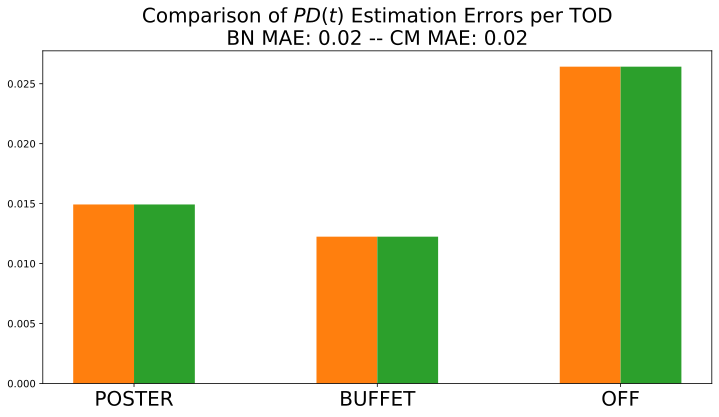

In [18]:
figs_pd = f'{OUTDIR}/figs_pd'
os.makedirs(figs_pd, exist_ok=True)

bn_err = []
cm_err = []

AUDITs = pickle.load(open(f"{OUTDIR}/AUDITs.pkl", "rb"))

for wp in WP:
    gts = []
    bayes_preds = []
    causal_preds = []
    wp_bin = 0
    
    bn = pyAgrum.loadBN(f"{OUTDIR}/CIE_{wp.value}.bifxml")
    cm = pyc.CausalModel(bn)
    dwp = pickle.load(open(f"{OUTDIR}/Ds.pkl", "rb"))[wp.value]
    _, _, midpoints_PD = get_info(dwp, AUDITs[wp.value], target_var)

    for idx_tod, tod in enumerate(TOD):
        if tod is TOD.STARTING: continue
        D_tod = load_specific_D(INDIR, BAGNAME, wp, tod)
        PD = np.mean(D_tod[target_var].values)
        gts.append(PD)
        
        # --- BN prediction ---
        ie = pyAgrum.VariableElimination(bn)
        bn_prior = ie.posterior(target_var)
        evidence = {intervention_var: idx_tod-1, "W": wp_bin}
        evidence_str = format_evidence_for_latex(evidence)
        ie.setEvidence(evidence)
        ie.makeInference()
        bn_posterior = ie.posterior(target_var)
        bn_posterior_values = bn_posterior.toarray()
        pred_bn = sum(bn_posterior_values[j] * midpoints_PD[j] for j in range(len(bn_posterior_values)))
        bayes_pred = (time/STEP)*pred_bn
                        
        # --- CausalModel prediction ---
        formula, adj, exp = pyc.causalImpact(cm, on=target_var, doing=intervention_var, knowing={"W"}, values=evidence)
        posterior_causal = adj.toarray()
        pred_causal = sum(posterior_causal[j] * midpoints_PD[j] for j in range(len(posterior_causal)))
        causal_pred = (time/STEP)*pred_causal
                        
        bayes_preds.append(float(bayes_pred))
        causal_preds.append(float(causal_pred))
        
    bn_errors = np.abs(np.array(bayes_preds)-np.array(gts))
    cm_errors = np.abs(np.array(causal_preds)-np.array(gts))
    
    bn_err.append(bn_errors)
    cm_err.append(cm_errors)

    # Define bar width and offsets
    bar_width = 0.25
    x_indexes = np.arange(len(TOD)-1)

    # Plot bars for each category with offset
    plt.figure(figsize=(12, 6))
    plt.bar(x_indexes - bar_width, gts, width=bar_width, label="Ground Truth", color='tab:blue', alpha=1)
    plt.bar(x_indexes, bayes_preds, width=bar_width, label=r"BN: E[$D$|$S$,$W$]", color='tab:orange', alpha=1)
    plt.bar(x_indexes + bar_width, causal_preds, width=bar_width, label=r"CM: E[$D$|do($S$),$W$]", color='tab:green', alpha=1)
    plt.xticks(x_indexes, [f"{tod.value}" for tod in TOD if tod != TOD.STARTING], fontsize=plot_fontsize)  # Format x-axis labels
    plt.savefig(f"{figs_pd}/{wp.value}.png")
    plt.close()
    
plt.figure(figsize=(12, 6))
plt.bar(x_indexes - bar_width/2, np.mean(bn_err, axis=0), width=bar_width, label=r"BN: E[$D$|$S$,$W$]", color='tab:orange', alpha=1)
plt.bar(x_indexes + bar_width/2, np.mean(cm_err, axis=0), width=bar_width, label=r"CM: E[$D$|do($S$),$W$]", color='tab:green', alpha=1)
plt.xticks(x_indexes, [f"{tod.value}" for tod in TOD if tod != TOD.STARTING], fontsize=plot_fontsize)  # Format x-axis labels
plt.title(r"Comparison of $PD(t)$ " + f"Estimation Errors per TOD\nBN MAE: {np.mean(np.mean(bn_err, axis=0), axis=0):.2f} -- CM MAE: {np.mean(np.mean(cm_err, axis=0), axis=0):.2f}", fontdict={'fontsize': plot_fontsize})
plt.show()

In [19]:
target_var = 'L'
target_var_str = format_evidence_for_latex({target_var: None})
intervention_var = "V"

static_duration = 5
dynamic_duration = 4
charging_time = 2
LOAD_FACTOR = 5
ROBOT_MAX_VEL = 0.5
K_nl_s = 100 / (static_duration * 3600)
K_nl_d = (100 / (dynamic_duration * 3600) - K_nl_s)/(ROBOT_MAX_VEL)
K_l_s = K_nl_s * LOAD_FACTOR
K_l_d = K_nl_d * LOAD_FACTOR

quantiles_V, edges_V, midpoints_V = get_info(D, auditDict, intervention_var)
quantiles_L, edges_L, midpoints_L = get_info(D, auditDict, target_var)
STEP = 0.1

plot_fontsize = 20

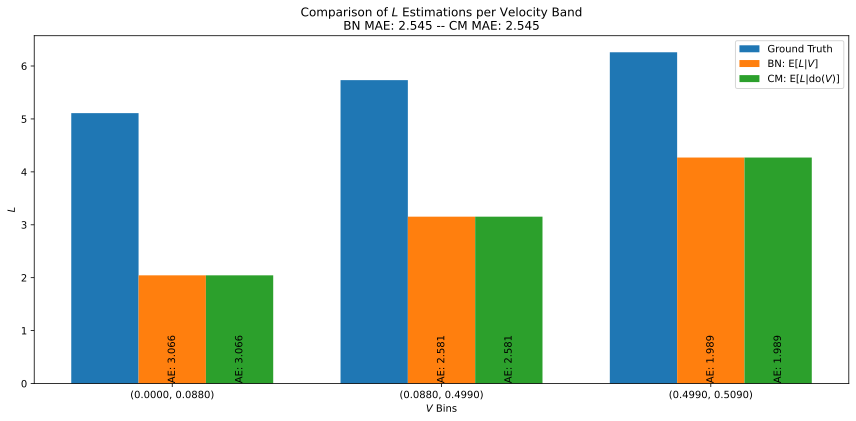

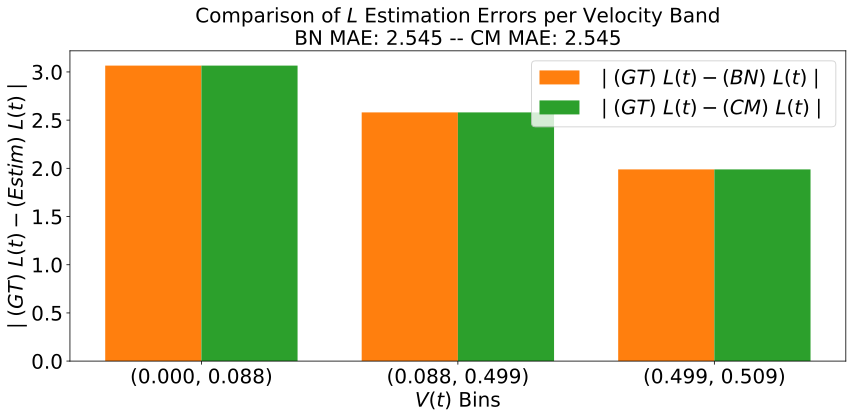

In [20]:
time = 300
gt_noload = []
gt_load = []
gts = []
bayes_preds = []
causal_preds = []

V_range = midpoints_V
for V_val in V_range:
    V_bin_idx = find_bin(V_val, edges_V)
    V_val = midpoints_V[V_bin_idx]
    GTLOAD = time * (K_l_s + K_l_d * V_val) 
    GTNOLOAD = time * (K_nl_s + K_nl_d * V_val)
        
    # --- BN prediction ---
    ie = pyAgrum.VariableElimination(bn)
    bn_prior = ie.posterior(target_var)
    evidence = {intervention_var: V_bin_idx, "W": 0, "S": 1}
    evidence_str = format_evidence_for_latex(evidence)
    ie.setEvidence(evidence)
    ie.makeInference()
    bn_posterior = ie.posterior(target_var)
    bn_posterior_values = bn_posterior.toarray()
    pred_bn = sum(bn_posterior_values[j] * midpoints_L[j] for j in range(len(bn_posterior_values)))
    bayes_pred = (time/STEP)*pred_bn
        
    # --- CausalModel prediction ---
    formula, adj, exp = pyc.causalImpact(cm, on=target_var, doing=intervention_var, knowing={"W", "S"}, values=evidence)
    posterior_causal = adj.toarray()
    pred_causal = sum(posterior_causal[j] * midpoints_L[j] for j in range(len(posterior_causal)))
    causal_pred = (time/STEP)*pred_causal
        
    gt_noload.append(GTNOLOAD)
    gt_load.append(GTLOAD)
    gts.append((GTNOLOAD+GTLOAD)/2)
    bayes_preds.append(bayes_pred)
    causal_preds.append(causal_pred)

# Define bar width and offsets
x_indexes = np.arange(len(V_range))

# Compute absolute errors
cm_errors = np.abs(np.array(causal_preds) - np.array(gts))
bn_errors = np.abs(np.array(bayes_preds) - np.array(gts))

# Compute Mean Absolute Error (MAE)
cm_MAE = np.mean(cm_errors)
bn_MAE = np.mean(bn_errors)


# Plot bars for each category with offset
plt.figure(figsize=(12, 6))
bar_width = 0.25
plt.bar(x_indexes - bar_width, gts, width=bar_width, label="Ground Truth", color='tab:blue', alpha=1)
plt.bar(x_indexes, bayes_preds, width=bar_width, label=r"BN: E[$L$|$V$]", color='tab:orange', alpha=1)
plt.bar(x_indexes + bar_width, causal_preds, width=bar_width, label=r"CM: E[$L$|do($V$)]", color='tab:green', alpha=1)

# Add absolute errors as text at the base of BN and CM bars
for i in range(len(x_indexes)):
    plt.text(x_indexes[i], 0.005, f"AE: {bn_errors[i]:.3f}", ha='center', va='bottom', fontsize=10, color='black', rotation=90)
    plt.text(x_indexes[i] + bar_width, 0.005, f"AE: {cm_errors[i]:.3f}", ha='center', va='bottom', fontsize=10, color='black', rotation=90)
    
# Labeling
plt.xlabel(r"$V$ Bins")
plt.ylabel(r"$L$")
plt.xticks(x_indexes, [f"({edges_V[i-1]:.4f}, {edges_V[i]:.4f})" for i in range(1, len(edges_V))])  # Format x-axis labels
plt.title(r"Comparison of $L$ " + f"Estimations per Velocity Band\nBN MAE: {bn_MAE:.3f} -- CM MAE: {cm_MAE:.3f}")
plt.legend()
plt.tight_layout()
plt.show()



# Plot bars for each category with offset
plt.figure(figsize=(12, 6))
bar_width = 0.375
plt.bar(x_indexes, bn_errors, width=bar_width, label=r"$\mid (GT)~L(t) - (BN)~L(t) \mid$", color='tab:orange', alpha=1)
plt.bar(x_indexes + bar_width, cm_errors, width=bar_width, label=r"$\mid (GT)~L(t) - (CM)~L(t) \mid$", color='tab:green', alpha=1)
   
# Labeling
plt.xlabel(r"$V(t)$ Bins", fontdict={'fontsize': plot_fontsize})
plt.ylabel(r"$\mid (GT)~L(t) - (Estim)~L(t) \mid$", fontdict={'fontsize': plot_fontsize})
plt.xticks(x_indexes+bar_width/2, [f"({edges_V[i-1]:.3f}, {edges_V[i]:.3f})" for i in range(1, len(edges_V))], fontdict={'fontsize': plot_fontsize})  # Format x-axis labels
plt.yticks(fontsize=plot_fontsize)  # Format x-axis labels
plt.title(r"Comparison of $L$ " + f"Estimation Errors per Velocity Band\nBN MAE: {bn_MAE:.3f} -- CM MAE: {cm_MAE:.3f}", fontdict={'fontsize': plot_fontsize})
plt.legend(fontsize=plot_fontsize)
plt.tight_layout()

plt.show()


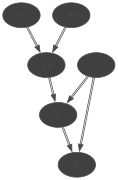

<IPython.core.display.Math object>

0.0007143051551519652


In [21]:
from IPython.display import Math
def find_bin(value, edges):
     """
     Given a continuous value and an array of bin edges,
     return the index of the bin that contains the value.
     """
     idx = np.digitize(value, edges, right=False) - 1
     return int(max(0, min(idx, len(edges) - 2)))
 
AUDITs = pickle.load(open(f"{OUTDIR}/AUDITs.pkl", "rb"))
Ds = pickle.load(open(f"{OUTDIR}/Ds.pkl", "rb"))
CIE = {}
for wp in WPS.keys():
    bn = pyAgrum.loadBN(f"{OUTDIR}/CIE_{wp}.bifxml")
    cm = pyc.CausalModel(bn)
    CIE[wp] = {'audit': AUDITs[wp], 'd': Ds[wp], 'bn': bn, 'cm': cm}
            
quantiles_V, edges_V, midpoints_V = get_info(Ds['r1'], AUDITs['r1'], "V") # r1 has been chosen as random wp
quantiles_L, edges_L, midpoints_L = get_info(Ds['r1'], AUDITs['r1'], "L") # r1 has been chosen as random wp
V_info = {'quantiles': quantiles_V, 'edges': edges_V, 'midpoints': midpoints_V}
L_info = {'quantiles': quantiles_L, 'edges': edges_L, 'midpoints': midpoints_L}
    
V_bin_idx = find_bin(0.5, V_info['edges'])

# --- CausalModel prediction ---
cm = CIE['r2']['cm']
# evidence = {"V": V_bin_idx}
evidence = {"V": V_bin_idx, "W": 0, "S": 1}
# evidence = {"V0": RV_bin_idx, "W0": 0, "S0": 1}
# _, adj, _ = pyc.causalImpact(cm, on="L0", doing="V0", values=evidence)
# 1. Capture the formula (it is the first return value)
cslnb.showCausalModel(cm)
# formula, adj, explanation = pyc.causalImpact(cm, on="L", doing="V", values=evidence)
formula, adj, explanation = pyc.causalImpact(cm, on="L", doing="V", knowing={"W", "S"}, values=evidence)
# 2. Render the formula in the notebook
display(Math(formula.toLatex()))

# _, adj, _ = pyc.causalImpact(cm, on="L0", doing="V0", knowing={"W0", "S0"}, values=evidence)
posterior_causal = adj.toarray()
pred_causal = sum(posterior_causal[j] * L_info['midpoints'][j] for j in range(len(posterior_causal)))
print(pred_causal)
# print(f"Predicted L0 for V0 in bin {RV_bin_idx} ({edges_V[RV_bin_idx]:.3f}, {edges_V[RV_bin_idx+1]:.3f}): {pred_causal:.3f}")